## Prediction with Best-F1 Threshold


In [56]:
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    precision_recall_curve, confusion_matrix, roc_auc_score,
    average_precision_score, classification_report, roc_curve
)
from irr.models.mlp_classifier import IrrMLPClassifier
from irr.constants import FEATURES, LABEL_COL
from IPython.display import display
import glob, os


In [57]:
# location of checkpoint/log from desired run with checks
run_dirs = glob.glob("../outputs/logs/mlp_classifier_tb/version_16") # adjust version number as needed
assert run_dirs, "No runs found"
latest_run = max(run_dirs, key=os.path.getmtime)

ckpts = glob.glob(os.path.join(latest_run, "checkpoints", "*.ckpt"))
assert ckpts, f"No checkpoints in {latest_run}"
CKPT_PATH = max(ckpts, key=os.path.getmtime)
print("Using ckpt:", os.path.normpath(CKPT_PATH))



CKPT_PATH = max(ckpts, key=os.path.getmtime)
DATA_GLOB = "../raw_data/WA*.csv"                                                 
OUT_CSV   = "notebooks/predictions/preds_all.csv"                                                                                        
BATCH_SIZE = 1024
DEVICE = "mps"

Using ckpt: ../outputs/logs/mlp_classifier_tb/version_16/checkpoints/033-0.9449.ckpt


In [58]:
# Load CSVs of new data for prediction
paths = sorted(glob.glob(DATA_GLOB))
if not paths:
    raise FileNotFoundError(f"No CSV files matched: {DATA_GLOB}")

dfs = []
for p in paths:
    df = pd.read_csv(p)
    missing = [c for c in FEATURES if c not in df.columns]
    if missing:
        raise ValueError(f"{p} missing feature columns: {missing}")
    df["_source_path"] = p  # keep origin for summaries
    dfs.append(df)

full = pd.concat(dfs, ignore_index=True)
full = full.dropna(subset=FEATURES).reset_index(drop=True)
print(f"Loaded {len(paths)} files → combined shape: {full.shape}")
full.head(3)

Loaded 5 files → combined shape: (94827, 74)


,system:index,A00,A01,A02,A03,A04,A05,A06,A07,A08,...,A63,cdl_code,county,county_fips,county_name,label,state,year,.geo,_source_path
0,0,-0.199862,-0.206936,-0.024606,-0.038447,0.113741,0.055363,0.103406,-0.084214,0.084214,...,-0.113741,122,<Feature>,11,Clark,0,WA,2018,"{""type"":""Point"",""coordinates"":[-122.4564466986...",../raw_data/WA_alphaearth_irrmapper_training_2...
1,1,0.038447,-0.172795,-0.062991,-0.130165,0.119093,0.019931,0.012057,-0.038447,0.015748,...,-0.059116,142,<Feature>,47,Okanogan,0,WA,2018,"{""type"":""Point"",""coordinates"":[-119.2385512939...",../raw_data/WA_alphaearth_irrmapper_training_2...
2,2,-0.124567,-0.048228,0.012057,-0.059116,-0.048228,-0.172795,-0.027128,0.172795,0.113741,...,0.059116,1,<Feature>,21,Franklin,1,WA,2018,"{""type"":""Point"",""coordinates"":[-119.3194910744...",../raw_data/WA_alphaearth_irrmapper_training_2...


In [59]:

# Load model from checkpoint
model = IrrMLPClassifier.load_from_checkpoint(CKPT_PATH, map_location="cpu", strict=False).eval().to(DEVICE)


/Users/tim/repos/pytorch_irr_model_modular/.venv/lib/python3.12/site-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['loss.pos_weight']


In [60]:

# build dataloader
X = torch.as_tensor(full[FEATURES].values, dtype=torch.float32)
pin = (DEVICE == "cuda")
dl = DataLoader(TensorDataset(X), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin)


In [61]:

# prediction probabilities
probs_list = []
with torch.no_grad():
    for (xb,) in dl:
        xb = xb.to(DEVICE, non_blocking=pin)
        p = model.predict_proba(xb)     # calibrated if model has it; else raw sigmoid
        probs_list.append(p.cpu())
probs = torch.cat(probs_list).numpy()   # (N,)

preds_df = full.copy()
preds_df["prob_irrigated"] = probs


In [62]:

# Find best F1 threshold from precision-recall curve
y_true = preds_df[LABEL_COL].astype(int).to_numpy()
y_prob = preds_df["prob_irrigated"].to_numpy()

prec, rec, thr = precision_recall_curve(y_true, y_prob)
f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)   # align with thr
best_idx = int(np.nanargmax(f1))
best_thr = float(thr[best_idx])

print(f"Best F1 threshold = {best_thr:.3f}  (P={prec[best_idx]:.3f}, R={rec[best_idx]:.3f})")

preds_df["pred_irrigated"] = (preds_df["prob_irrigated"].to_numpy() >= best_thr).astype(int)
preds_df["used_threshold"] = best_thr


Best F1 threshold = 0.612  (P=0.840, R=0.831)


AUROC=0.9921  |  AUPRC=0.9191


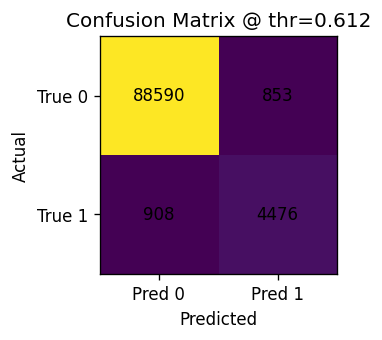

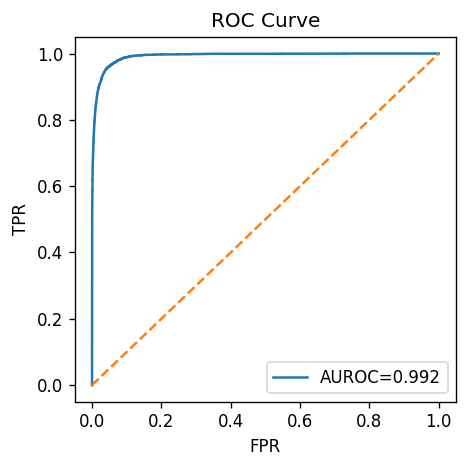

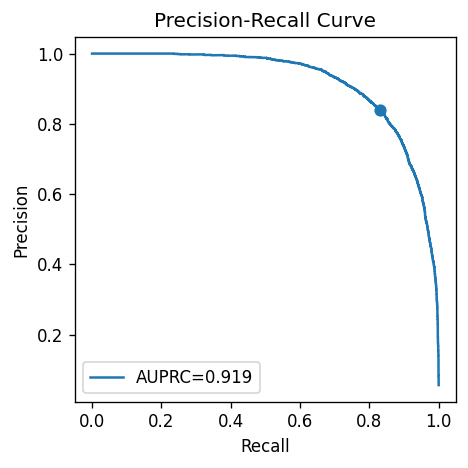

              precision    recall  f1-score   support

           0     0.9899    0.9905    0.9902     89443
           1     0.8399    0.8314    0.8356      5384

    accuracy                         0.9814     94827
   macro avg     0.9149    0.9109    0.9129     94827
weighted avg     0.9813    0.9814    0.9814     94827



In [63]:

# PLots
auroc = roc_auc_score(y_true, y_prob)
auprc = average_precision_score(y_true, y_prob)
print(f"AUROC={auroc:.4f}  |  AUPRC={auprc:.4f}")

# Confusion matrix at best-F1 threshold
cm = confusion_matrix(y_true, preds_df["pred_irrigated"].to_numpy(), labels=[0,1])
fig, ax = plt.subplots(figsize=(3,3), dpi=120)
ax.imshow(cm, interpolation="nearest")
ax.set_title(f"Confusion Matrix @ thr={best_thr:.3f}")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["Pred 0","Pred 1"])
ax.set_yticklabels(["True 0","True 1"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(int(cm[i, j])), ha="center", va="center")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

# ROC
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(4,4), dpi=120)
plt.plot(fpr, tpr, label=f"AUROC={auroc:.3f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend(); plt.tight_layout(); plt.show()

# Precision-Recall with marked best-F1 point
plt.figure(figsize=(4,4), dpi=120)
plt.plot(rec, prec, label=f"AUPRC={auprc:.3f}")
plt.scatter([rec[best_idx]], [prec[best_idx]], s=40)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(); plt.tight_layout(); plt.show()

print(classification_report(y_true, preds_df['pred_irrigated'], digits=4))


In [64]:
yt = preds_df[LABEL_COL].astype(int).to_numpy()
yp = (preds_df["prob_irrigated"].to_numpy() >= best_thr).astype(int)

tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()

overall_cm = pd.DataFrame(
    {
        "TN": [tn],
        "FP": [fp],
        "FN": [fn],
        "TP": [tp],
        "support": [len(yt)],
        "accuracy": [(tn + tp) / len(yt)],
        "precision": [tp / max(tp + fp, 1)],
        "recall": [tp / max(tp + fn, 1)],
        "f1": [2 * tp / max(2 * tp + fp + fn, 1)],
    },
    index=["ALL"],
)
display(overall_cm)


,TN,FP,FN,TP,support,accuracy,precision,recall,f1
ALL,88590,853,908,4476,94827,0.981429,0.839932,0.831352,0.83562


In [65]:

# save predictions csv
from pathlib import Path
out_path = Path(OUT_CSV)
out_path.parent.mkdir(parents=True, exist_ok=True)
preds_df.to_csv(out_path, index=False)
print(f"Wrote predictions to {out_path.resolve()}  | rows={len(preds_df):,}  | batch_size={BATCH_SIZE}")


Wrote predictions to /Users/tim/repos/pytorch_irr_model_modular/notebooks/notebooks/predictions/preds_all.csv  | rows=94,827  | batch_size=1024


In [66]:

# Per-year & Per-county breakdowns

# extract year from _source_path if not present
if "year" not in preds_df.columns:
    preds_df["year"] = preds_df["_source_path"].astype(str).apply(
        lambda s: int(re.search(r"20\d{2}", s).group())
    )

# Label counts by year
by_year = preds_df.groupby("year")[LABEL_COL].value_counts().unstack(fill_value=0).sort_index()
print("\nLabel counts by year (head):")
display(by_year.head(10))

# Confusion counts per county_name at best-F1 threshold
def cm_counts(g: pd.DataFrame):
    yt = g[LABEL_COL].astype(int).to_numpy()
    yp = (g["prob_irrigated"].to_numpy() >= best_thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0,1]).ravel()
    return pd.Series(dict(TN=tn, FP=fp, FN=fn, TP=tp, support=len(g)))

county_cm = preds_df.groupby("county_name").apply(cm_counts).sort_values("support", ascending=False)
print("\nPer-county confusion counts @ best-F1 threshold (head):")
display(county_cm.head(10))



Label counts by year (head):


label,0,1
year,,
2018,17835,1096
2019,17822,1112
2020,17913,1086
2021,17934,1063
2022,17939,1027



Per-county confusion counts @ best-F1 threshold (head):


/var/folders/30/ts9qnzxs1p90140qbxntdc7m0000gn/T/ipykernel_42050/938682767.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  county_cm = preds_df.groupby("county_name").apply(cm_counts).sort_values("support", ascending=False)


,TN,FP,FN,TP,support
county_name,,,,,
Okanogan,7202,10,33,87,7332
Yakima,5182,33,149,602,5966
Chelan,4137,4,15,42,4198
Grant,2616,42,86,1156,3900
Stevens,3474,18,43,46,3581
Lewis,3288,77,12,25,3402
Kittitas,3041,2,47,214,3304
Lincoln,3089,31,39,83,3242
Ferry,3174,0,3,6,3183
